In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv('C:/Users/Prem/loan-approval-ml-project/data/loan_data.csv')

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(381, 13)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,381.0,3579.845144,1419.813818,150.0,2600.0,3333.0,4288.0,9703.0
CoapplicantIncome,381.0,1277.275381,2340.818114,0.0,0.0,983.0,2016.0,33837.0
LoanAmount,381.0,104.986877,28.358464,9.0,90.0,110.0,127.0,150.0
Loan_Amount_Term,370.0,340.864865,68.549257,12.0,360.0,360.0,360.0,480.0
Credit_History,351.0,0.837607,0.369338,0.0,1.0,1.0,1.0,1.0


In [9]:
df.isnull().sum()

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
df['Loan_Status'].value_counts()

Loan_Status
Y    271
N    110
Name: count, dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [14]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(exclude='object').columns.tolist()

print('Categorical Columns:', cat_cols)
print('Numerical Columns:', num_cols)

Categorical Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
Numerical Columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


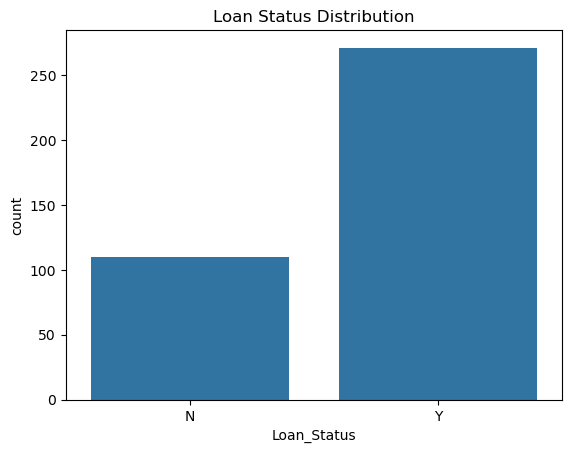

In [15]:
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Status Distribution')
plt.show()

## 271 people got the loan, while 110 doesn't got the loan.

In [16]:
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))


Value counts for Loan_ID:
Loan_ID
LP001003    1
LP002281    1
LP002314    1
LP002308    1
LP002305    1
           ..
LP001698    1
LP001693    1
LP001692    1
LP001691    1
LP002990    1
Name: count, Length: 381, dtype: int64

Value counts for Gender:
Gender
Male      291
Female     85
NaN         5
Name: count, dtype: int64

Value counts for Married:
Married
Yes    228
No     153
Name: count, dtype: int64

Value counts for Dependents:
Dependents
0      234
2       59
1       52
3+      28
NaN      8
Name: count, dtype: int64

Value counts for Education:
Education
Graduate        278
Not Graduate    103
Name: count, dtype: int64

Value counts for Self_Employed:
Self_Employed
No     325
Yes     35
NaN     21
Name: count, dtype: int64

Value counts for Property_Area:
Property_Area
Semiurban    149
Urban        126
Rural        106
Name: count, dtype: int64

Value counts for Loan_Status:
Loan_Status
Y    271
N    110
Name: count, dtype: int64


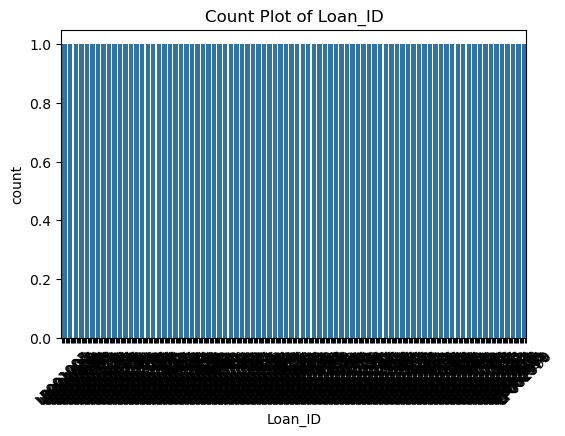

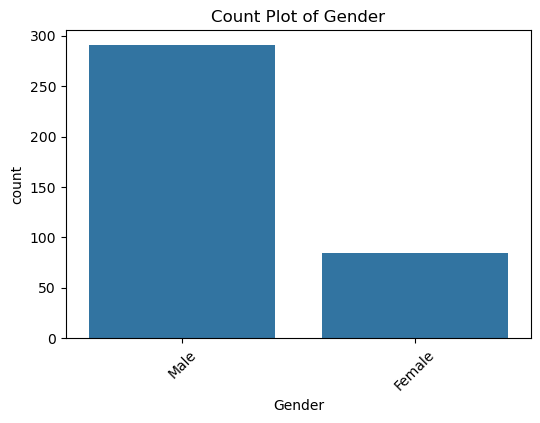

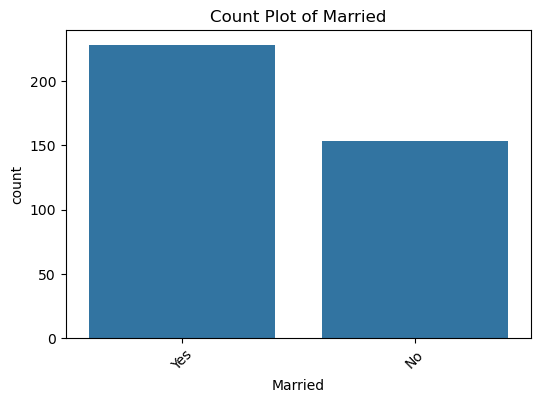

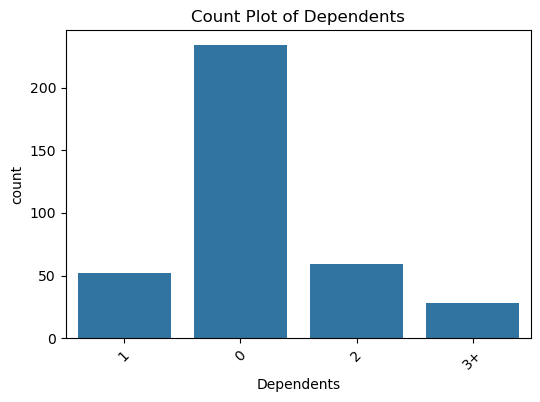

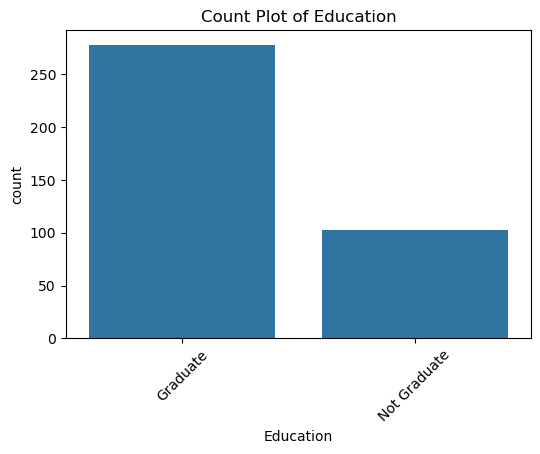

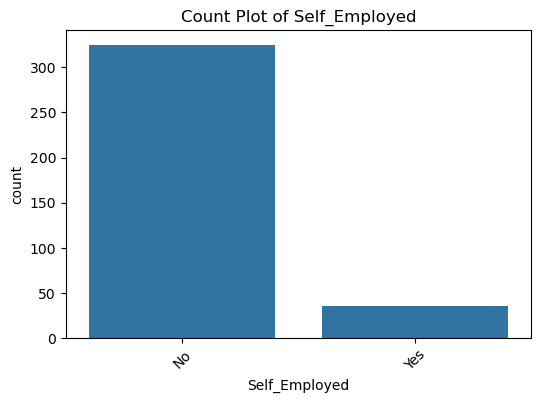

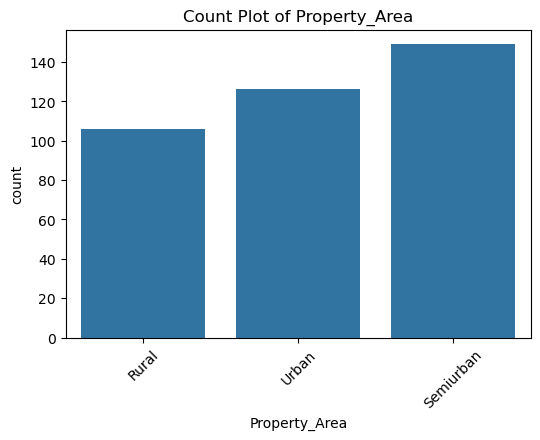

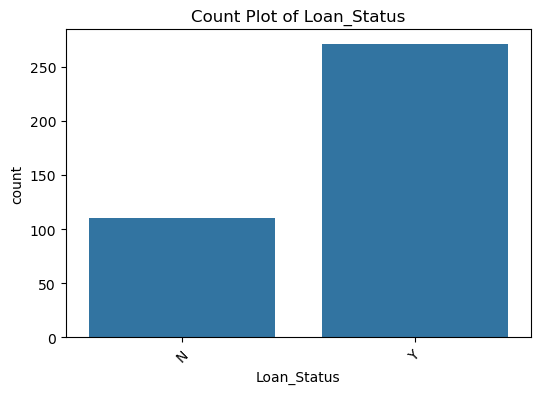

In [17]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

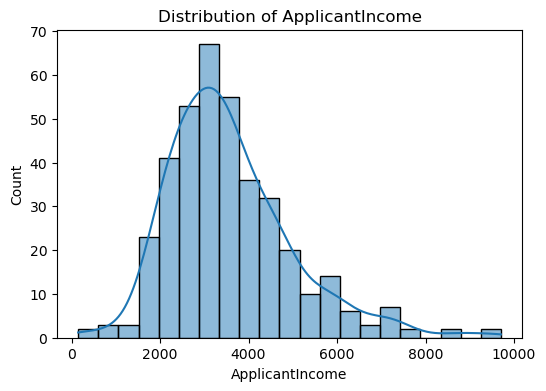

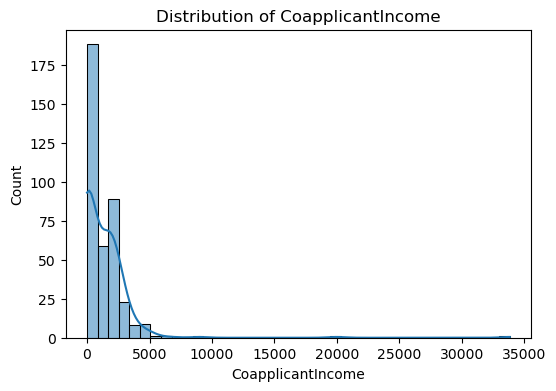

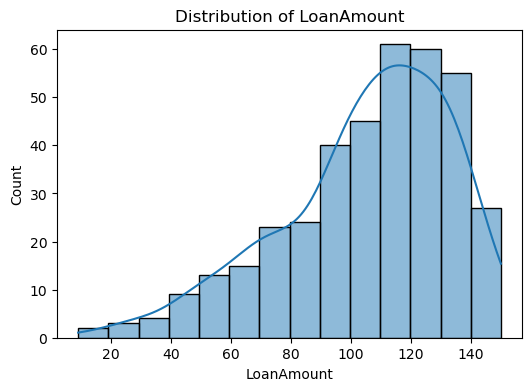

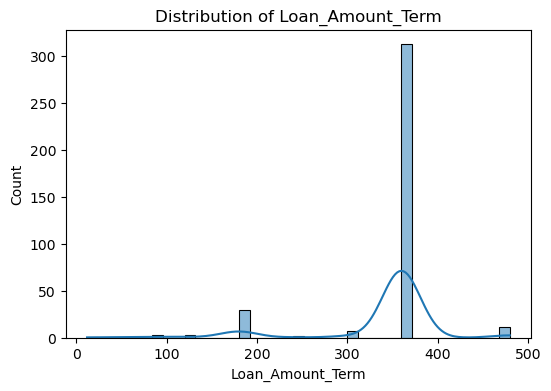

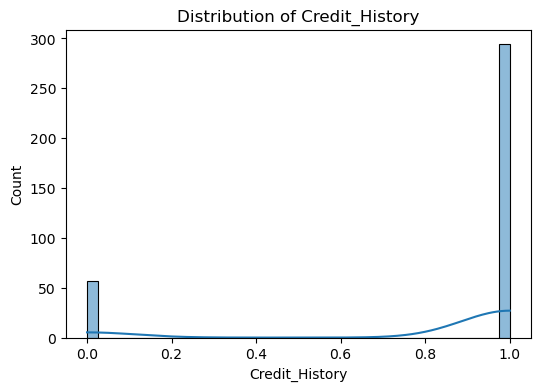

In [18]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

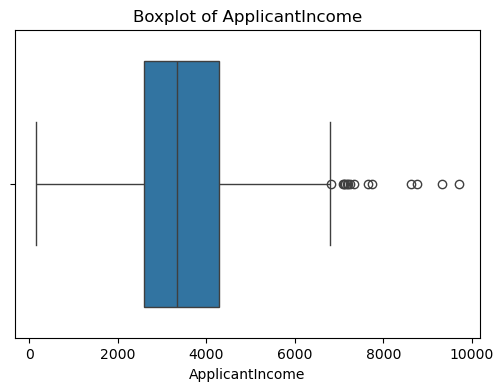

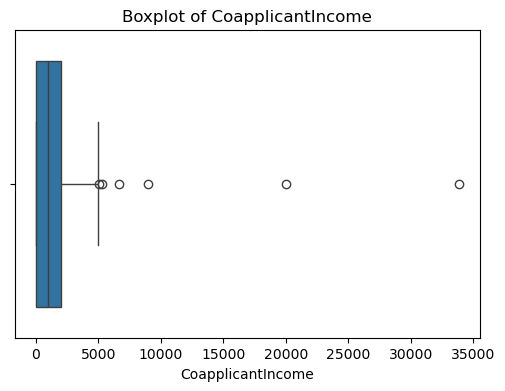

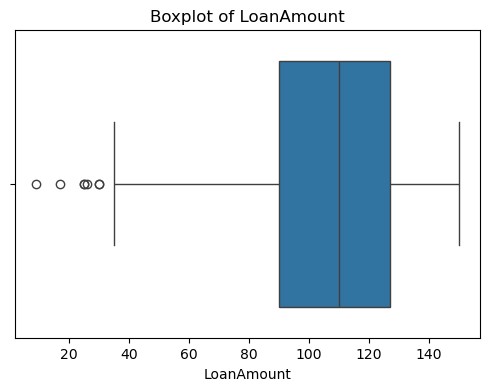

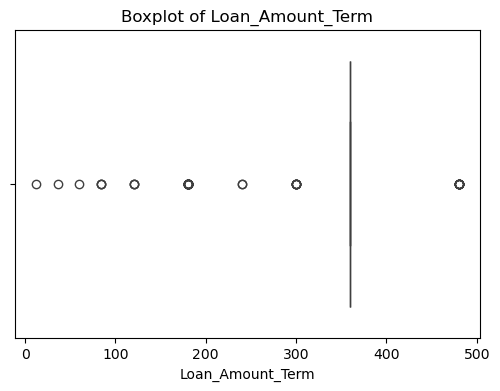

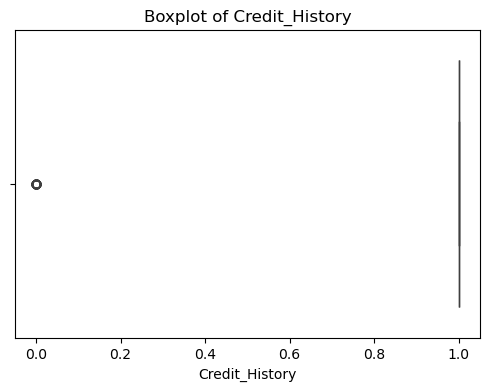

In [19]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Got the Outliers in Applicant Income, Coapplicant income, Loan amount.

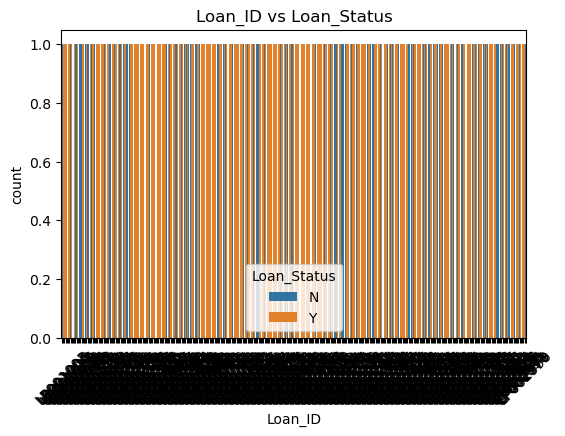

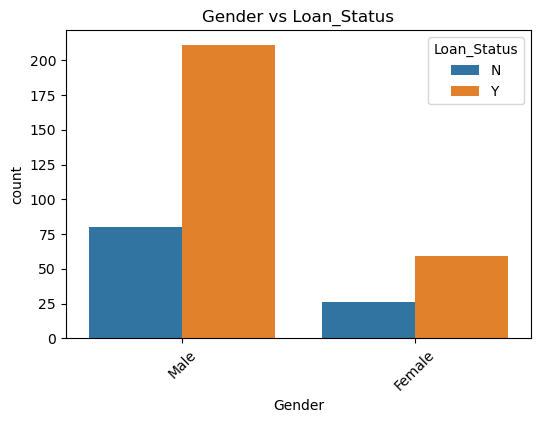

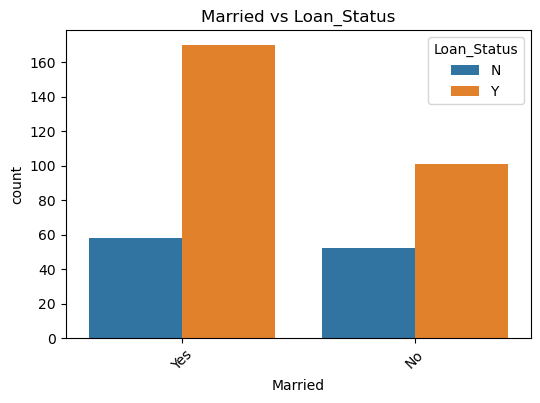

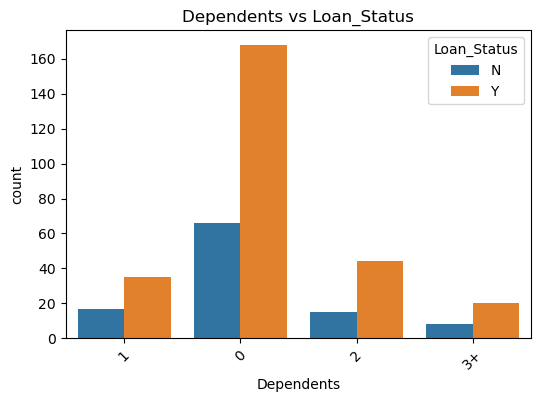

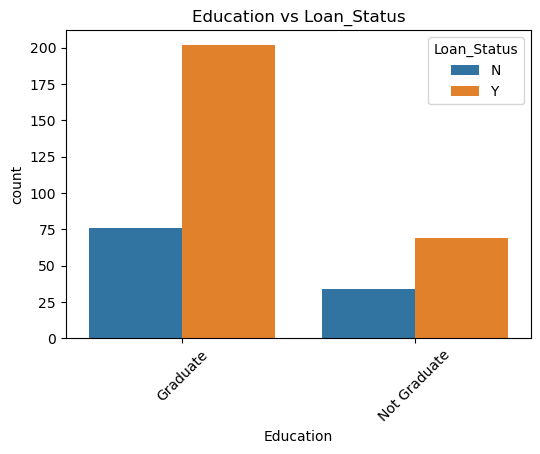

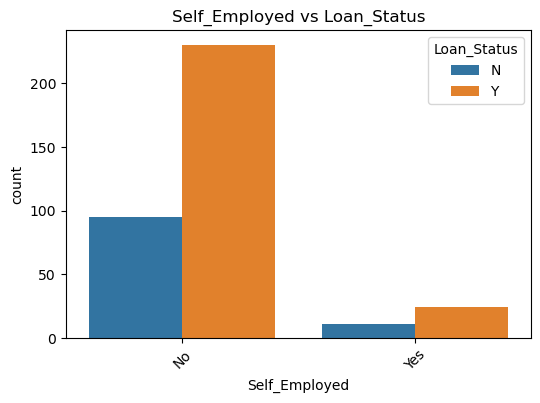

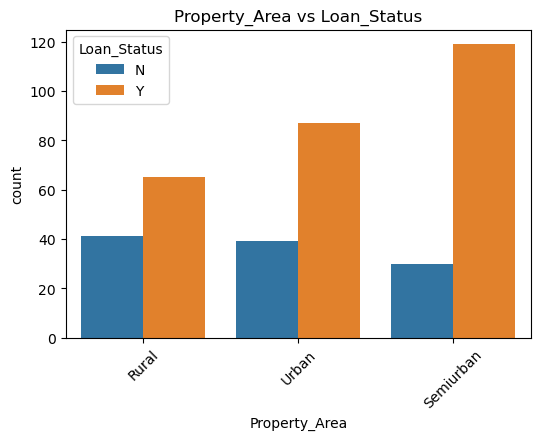

In [20]:
for col in cat_cols:
    if col != 'Loan_Status':
        plt.figure(figsize=(6,4))
        sns.countplot(x=col, hue='Loan_Status', data=df)
        plt.title(f"{col} vs Loan_Status")
        plt.xticks(rotation=45)
        plt.show()

## In the dataset, approved loans are more frequent among males, married, 0 dependents, graduated, non-self employed, semiurban property areas people.

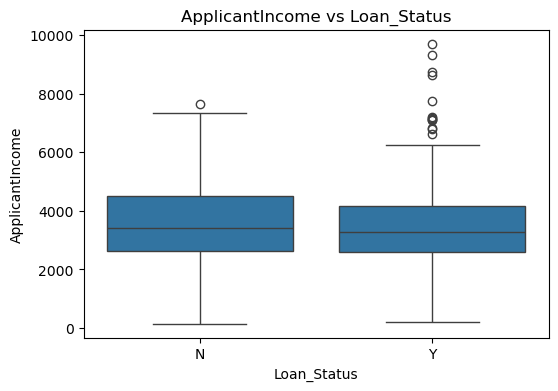

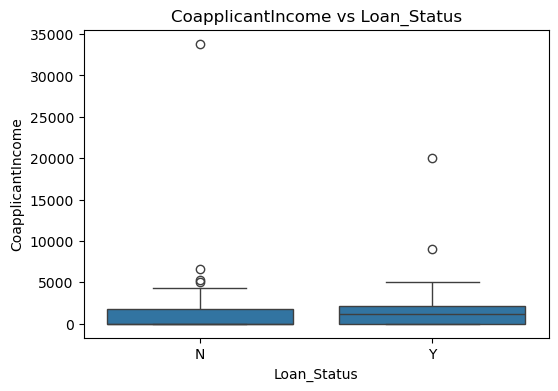

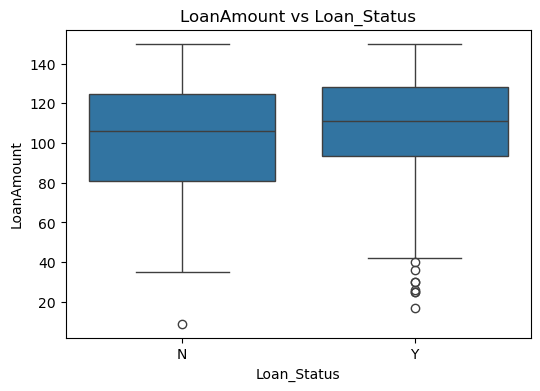

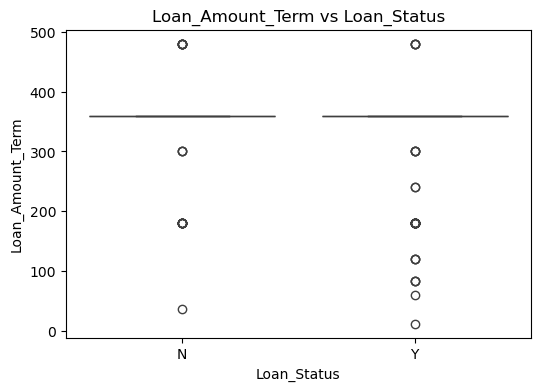

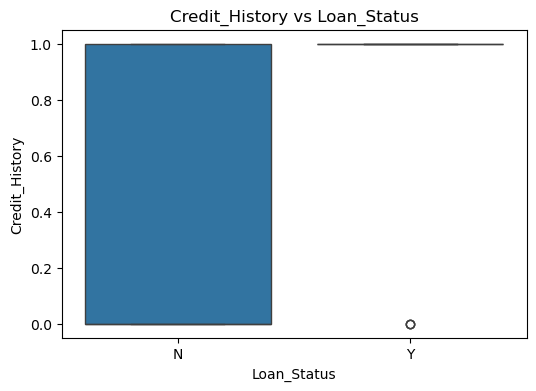

In [23]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Loan_Status', y=col, data=df)
    plt.title(f"{col} vs Loan_Status")
    plt.show()

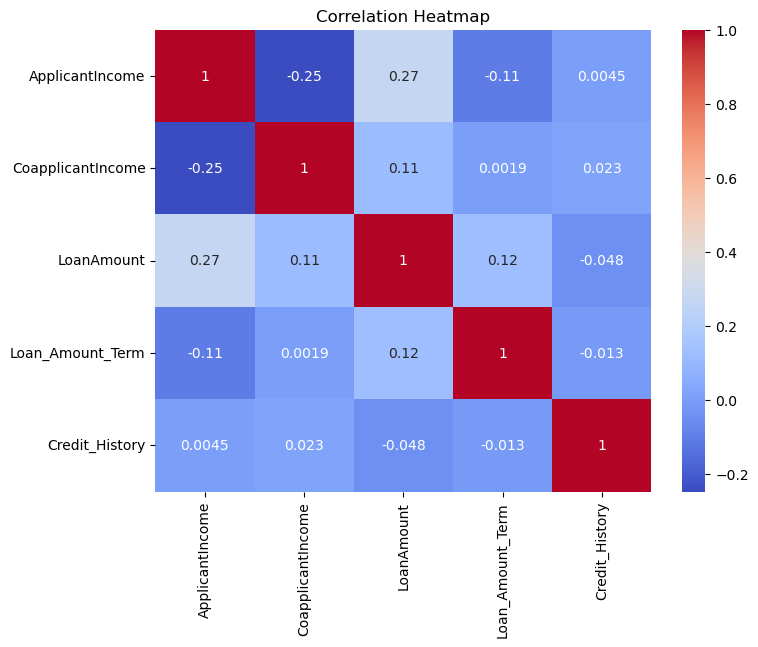

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## There is no strong multicollinearity-like issue visible among the numerical features.

## EDA Findings 
### 1. The target variable Loan_Status is imbalanced, with approved loans (Y) significantly higher than rejected loans (N).
### 2. Missing values are present in Gender, Dependents, Self_Employed, Loan_Amount_Term, and Credit_History.
### 3. Numerical features such as ApplicantIncome, CoapplicantIncome, and LoanAmount contain outliers.
### 4. Credit_History appears to have a strong relationship with loan approval based on target-wise visual analysis.
### 5. Most numerical features have weak correlations with one another, indicating no strong linear dependency among them.
### 6. ApplicantIncome has a weak positive correlation with LoanAmount, while ApplicantIncome and CoapplicantIncome show a weak negative relationship.